In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap

plt.style.use('../plotstyling.mplstyle')

In [2]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
ds = xr.open_dataset(db_filename)

In [10]:
NEDeltaT = np.array([0.36, 0.50, 0.56, 0.79, 0.84, 1.0, 0.80, 0.95, 1.53, 1.6])

Fwp = ds.Fwp.values
Fwc = ds.Fwc.values
Zm = ds.Fwp_Zm.values / 1000
Latitude = ds.Latitude.values
Longitude = ds.Longitude.values
Surf_z = ds.Surf_Z.values
altitude = ds.vertical_level.values / 1000
altitude_in_m = ds.vertical_level.values

channels = ["AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:,i] = ds[f"Ta_Allsky_{ch}"].values

CS_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array[:,i] = ds[f"Ta_Clearsky_{ch}"].values - ds[f"Ta_Allsky_{ch}"].values

CS_diff_array = np.zeros((Latitude.shape[0], len(channels)-1))
for i in range(len(channels)-1):
    CS_diff_array[:,i] = CS_array[:,i] - CS_array[:,i+1]

CS_pair_diff_array = np.zeros((Latitude.shape[0], 4))
CS_pair_diff_array[:,0] = ds[f"Ta_Clearsky_AWS33"].values - ds[f"Ta_Allsky_AWS44"].values
CS_pair_diff_array[:,1] = ds[f"Ta_Clearsky_AWS34"].values - ds[f"Ta_Allsky_AWS43"].values
CS_pair_diff_array[:,2] = ds[f"Ta_Clearsky_AWS35"].values - ds[f"Ta_Allsky_AWS42"].values
CS_pair_diff_array[:,3] = ds[f"Ta_Clearsky_AWS36"].values - ds[f"Ta_Allsky_AWS41"].values

CS_bins = np.linspace(-5,5,100)

CS_diff_bins = np.linspace(-10,50,100)

deviation_bins = np.linspace(-10, 10, 101)
deviation_bins_centre = deviation_bins[:-1] + np.diff(deviation_bins) / 2

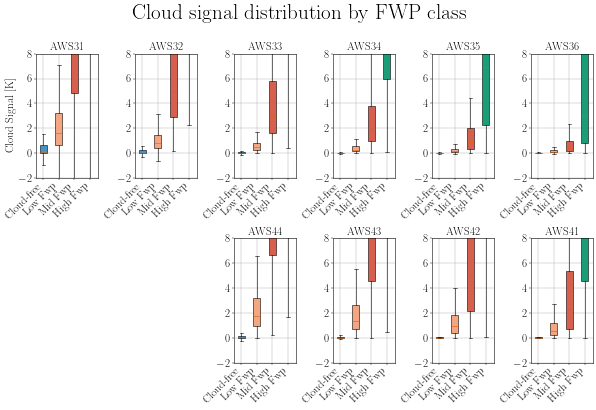

In [23]:
labels = [r"FWP $< 10^{-2}$", r"$10^{-2} <$ FWP $< 10^{0}$", r"FWP $> 10^{0}$"]

fwp_masks = [
    (Fwp < 1e-2),
    ((Fwp >= 1e-2) & (Fwp < 1e-1)),
    ((Fwp >= 1e-1) & (Fwp < 1e0)),
    (Fwp >= 1e0),
]


masks = [
    (np.abs(Latitude) < 20) & fwp_mask for fwp_mask in fwp_masks
]

mask_labels = [
        "Cloud-free",
    "Low Fwp",
    "Mid Fwp",
    "High Fwp",
]
# ── plot 

# ── plot ──
fig, axes_2d = plt.subplots(2, 6, figsize=(15, 10))

axes = axes_2d.flatten()

for j, ch in enumerate(channels):
    if int(ch[-2:]) < 40:
        ax = axes_2d[0,j]
    else:
        ax = axes_2d[1,j-4]

    data = [CS_array[mask, j] for mask in masks]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False)
    
    colors = ["#4393c3", "#f4a582", "#d6604d"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f"{ch}")
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(mask_labels,
                    rotation=45, ha="right")
    ax.grid()

    ax.set_ylim([-2,8])

axes_2d[1,0].set_visible(False)
axes_2d[1,1].set_visible(False)

axes_2d[0,0].set_ylabel("Cloud Signal [K]")
axes_2d[1,0].set_ylabel("Cloud Signal [K]")

fig.suptitle("Cloud signal distribution by FWP class", y=1.02)

plt.tight_layout()
plt.savefig("../figures/CS_boxplot_FWP.png", dpi=200, bbox_inches="tight", facecolor="white")

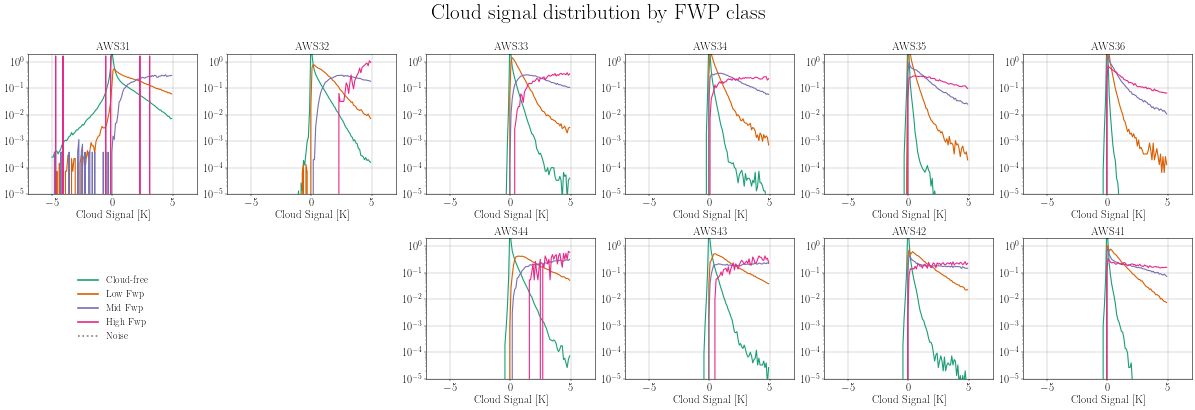

In [24]:
"""
fwp_masks = [
    (Fwp < 1e-2),
    (Fwp >= 1e-2) & (Fwp < 1e0) & (Zm < 8),
    (Fwp >= 1e-2) & (Fwp < 1e0) & (Zm > 8),
    (Fwp >= 1e0) & (Zm < 8),
    (Fwp >= 1e0) & (Zm >= 8),
]
"""
fwp_masks = [
    (Fwp < 1e-2),
    ((Fwp >= 1e-2) & (Fwp < 1e-1)),
    ((Fwp >= 1e-1) & (Fwp < 1e0)),
    (Fwp >= 1e0),
]


masks = [
    (np.abs(Latitude) < 20) & fwp_mask for fwp_mask in fwp_masks
]
#mask_labels = [r"$<10^{-1}$", r"$10^{-1}$–$10^{0}$", r"$>10^{0}$"]

mask_labels = [
        "Cloud-free",
    "Low Fwp",
    "Mid Fwp",
    "High Fwp",
       #"Low ice, low altitude",
       #"Low ice, high altitude",
       #"High ice, low altitude",
      #"High ice, high altitude",
    #"Anvil cirrus",
    #"CC",
]
# ── plot ──
# ── plot ──
fig, axes_2d = plt.subplots(2, 6, figsize=(30, 10))

axes = axes_2d.flatten()
colors = ["#4393c3", "#f4a582", "#d6604d"]

for j, ch in enumerate(channels):
    if int(ch[-2:]) < 40:
        ax = axes_2d[0,j]
    else:
        ax = axes_2d[1,j-4]

    for i, mask in enumerate(masks):
        data = CS_array[mask, j]
        counts, _ = np.histogram(data, CS_bins, density=True)
        ax.plot(CS_bins[:-1], counts, color=f"C{i}", label=mask_labels[i], lw=2)
    
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f"{ch}")
    #ax.set_xticks([1, 2, 3])
    #ax.set_xticklabels([r"$<10^{-1}$", r"$10^{-1}$–$10^{0}$", r"$>10^{0}$"],
    #                rotation=45, ha="right")
    ax.grid()
    ax.set_yscale("log")
    ax.set_ylim([1e-5, 2e0])

    ax.set_xlabel("Cloud Signal [K]")

    """
    # plotting noise for reference
    noisy_samples = np.random.normal(loc=0, scale=NEDeltaT[j], size=100000)
    noise_distribution, _ = np.histogram(noisy_samples, bins=deviation_bins, density=True)
    ax.plot(deviation_bins_centre, noise_distribution, color="grey", label="Noise", ls=":")
    """
    ax.set_xlim([-7,7])

axes_2d[0,0].legend()

axes_2d[1,1].set_visible(False)
axes_2d[1,0].set_visible(True)
axes_2d[1,0].axis("off")

# create legend handles manually
handles = [plt.Line2D([0], [0], color=f"C{i}", label=mask_labels[i]) 
           for i in range(len(masks))]
handles.append(plt.Line2D([0], [0], color="grey", ls=":", label="Noise"))
axes_2d[1,0].legend(handles=handles, loc="center", frameon=False)

# remove legend from the channel plot
axes_2d[0,0].get_legend().remove()

fig.suptitle("Cloud signal distribution by FWP class", y=1.02)

plt.tight_layout()
plt.savefig("../figures/CS_distribution_FWP.png", dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
for label, mask in zip(mask_labels, masks):
    print(f"{label}: {mask.sum()}")



In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# profiles with high FWP but very low cloud signal
suspect_mask = (Fwp >= 1e0) & (CS_array[:,-4] < 2) & (np.abs(Latitude) < 20)
print(np.sum(suspect_mask))
fig, ax = plt.subplots(figsize=(14, 7),
                       subplot_kw={"projection": ccrs.PlateCarree()})

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

# plot all high FWP points for context
ax.scatter(Longitude[Fwp >= 1e0], Latitude[Fwp >= 1e0],
           s=0.5, color="steelblue", alpha=0.2, transform=ccrs.PlateCarree(),
           label="High FWP")

# highlight suspect points
ax.scatter(Longitude[suspect_mask], Latitude[suspect_mask],
           s=5, color="red", alpha=0.8, transform=ccrs.PlateCarree(),
           label=f"High FWP, CS < 3K (n={suspect_mask.sum()})")

ax.set_global()
ax.legend(markerscale=5, loc="lower left")
ax.set_title("High FWP profiles with suspiciously low cloud signal")


In [ ]:
CS_array.shape

In [ ]:

# ── plot ──
fig, axes_2d = plt.subplots(2, 6, figsize=(30, 10))

axes = axes_2d.flatten()
colors = ["#4393c3", "#f4a582", "#d6604d"]

for j, ch in enumerate(channels):
    if j == 9:
        break
        
    if int(ch[-2:]) < 40:
        ax = axes_2d[0,j]
    else:
        ax = axes_2d[1,j-4]

    for i, mask in enumerate(masks):
        data = CS_diff_array[mask, j]
        counts, _ = np.histogram(data, CS_diff_bins, density=True)
        ax.plot(CS_diff_bins[:-1], counts, color=f"C{i}", label=mask_labels[i])
    
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f"{ch}-{channels[j+1]}")
    #ax.set_xticks([1, 2, 3])
    #ax.set_xticklabels([r"$<10^{-1}$", r"$10^{-1}$–$10^{0}$", r"$>10^{0}$"],
    #                rotation=45, ha="right")
    ax.grid()
    ax.set_yscale("log")
    ax.set_ylim([1e-5, 2e0])

axes_2d[0,0].legend()

axes_2d[1,0].set_visible(False)
axes_2d[1,1].set_visible(False)

axes_2d[0,0].set_xlabel("Cloud Signal [K]")
axes_2d[1,0].set_xlabel("Cloud Signal [K]")

fig.suptitle("Cloud signal distribution by FWP category", y=1.02)

plt.tight_layout()
plt.savefig("../figures/CS_diff_distribution_FWP.png", dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(25, 10))


for j in range(4):
    
    ax = axes[j]

    for i, mask in enumerate(masks):
        data = CS_pair_diff_array[mask, j]
        counts, _ = np.histogram(data, CS_diff_bins, density=True)
        ax.plot(CS_diff_bins[:-1], counts, color=f"C{i}", label=mask_labels[i])
    
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    
    #ax.set_title(f"{ch}-{channels[j+1]}")
    #ax.set_xticks([1, 2, 3])
    #ax.set_xticklabels([r"$<10^{-1}$", r"$10^{-1}$–$10^{0}$", r"$>10^{0}$"],
    #                rotation=45, ha="right")
    ax.grid()
    ax.set_yscale("log")
    ax.set_ylim([1e-5, 2e0])

axes[0].legend()

#axes_2d[0,0].set_xlabel("Cloud Signal [K]")
#axes_2d[1,0].set_xlabel("Cloud Signal [K]")

fig.suptitle("Cloud signal distribution by FWP category", y=1.02)

plt.tight_layout()
plt.savefig("../figures/CS_pair_diff_distribution_FWP.png", dpi=200, bbox_inches="tight", facecolor="white")

In [20]:
for (j1, ch1), (j2, ch2) in combinations(enumerate(channels), 2):
    fig, ax = plt.subplots(figsize=(7, 6))
    
    for i, mask in enumerate(masks):
        x = CS_array[mask, j1]
        y = CS_array[mask, j2]
        
        h, xedges, yedges = np.histogram2d(x, y, bins=CS_bins, density=True)
        
        # cell centres for contour
        xc = (xedges[:-1] + xedges[1:]) / 2
        yc = (yedges[:-1] + yedges[1:]) / 2
        
        ax.contour(xc, yc, h.T, levels=[1e-3], colors=[f"C{i}"], linewidths=1.5)
        ax.scatter([], [], color=f"C{i}", label=mask_labels[i], s=10)
    
    ax.set_xlabel(f"CS {ch1} [K]")
    ax.set_ylabel(f"CS {ch2} [K]")
    ax.set_title(f"{ch1} vs {ch2}")
    ax.legend(fontsize=10)
    ax.grid()
    
    plt.tight_layout()
    plt.savefig(
        f"../figures/classification/CS_scatter_pairs/CS_scatter_{ch1}_vs_{ch2}.png",
        dpi=150, bbox_inches="tight", facecolor="white"
    )
    plt.close()

/home/eleanor/mambaforge/envs/aws/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:1077: RuntimeWarning: invalid value encountered in divide
  hist /= s


In [ ]:
diffs = np.column_stack([CS_array[:, i] - CS_array[:, i+1] for i in range(len(channels)-1)])
diff_labels = [f"{channels[i]}–{channels[i+1]}" for i in range(len(channels)-1)]

for (j1, dl1), (j2, dl2) in combinations(enumerate(diff_labels), 2):
    fig, ax = plt.subplots(figsize=(7, 6))
    
    for i, mask in enumerate(masks):
        x = diffs[mask, j1]
        y = diffs[mask, j2]
        
        h, xedges, yedges = np.histogram2d(x, y, bins=CS_bins, density=True)
        
        xc = (xedges[:-1] + xedges[1:]) / 2
        yc = (yedges[:-1] + yedges[1:]) / 2
        
        ax.contour(xc, yc, h.T, levels=[1e-3], colors=[f"C{i}"], linewidths=1.5)
        ax.scatter([], [], color=f"C{i}", label=mask_labels[i], s=10)
    
    ax.set_xlabel(f"CS diff {dl1} [K]")
    ax.set_ylabel(f"CS diff {dl2} [K]")
    ax.set_title(f"{dl1} vs {dl2}")
    ax.legend()
    ax.grid()
    
    plt.tight_layout()
    plt.savefig(
        f"../figures/classification/CS_scatter_pairs_diff/CS_scatter_diff_{dl1}_vs_{dl2}.png",
        dpi=150, bbox_inches="tight", facecolor="white"
    )
    plt.close()

In [ ]:
filter_idxs = np.where(
        (Latitude < 30)
        & (Latitude > -30)
    )[0]

In [ ]:

# ── prepare data ──
X = CS_array[filter_idxs]
y = np.log10(Fwp[filter_idxs])

# remove any NaN/inf
valid = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
X, y = X[valid], y[valid]

# ── train/test split ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── fit ──
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R² = {r2_score(y_test, y_pred):.3f}")

# ── plot predicted vs actual ──

h, xedges, yedges = np.histogram2d(y_test, y_pred, bins=100, density=True)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.pcolormesh(xedges, yedges, h.T, cmap="YlOrRd", norm=LogNorm())
plt.colorbar(im, ax=ax, label="Density")

lims = [y.min(), y.max()]
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")

ax.set_xlim([-3,2])
ax.set_ylim([-3,2])
tick_vals = [-3, -2, -1, 0, 1, 2]
tick_labels = [r"$10^{" + str(v) + r"}$" for v in tick_vals]
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_vals)
ax.set_yticklabels(tick_labels)

ax.set_xlabel(r"Actual FWP [$\mathrm{kg\;m^{-2}}$]")
ax.set_ylabel(r"Predicted FWP [$\mathrm{kg\;m^{-2}}$]")
ax.set_title(f"Linear regression: CS → FWP\nR² = {r2_score(y_test, y_pred):.3f}")
ax.legend()

plt.tight_layout()


In [ ]:
cm_true = confusion_matrix(y_test, y_pred, normalize="true").T
cm_pred = confusion_matrix(y_test, y_pred, normalize="pred").T

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cm, title in zip(axes,
                          [cm_true, cm_pred],
                          ["Conditioned on True", "Conditioned on Predicted"]):
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label="Fraction")

    ax.set_xticks(range(len(mask_labels)))
    ax.set_yticks(range(len(mask_labels)))
    ax.set_xticklabels(mask_labels, rotation=45, ha="right")
    ax.set_yticklabels(mask_labels)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(title)

    for i in range(len(mask_labels)):
        for j in range(len(mask_labels)):
            ax.text(j, i, f"{cm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm[i, j] > 0.5 else "black",
                    fontsize=10)

plt.tight_layout()
plt.savefig("../figures/classification/LDA_confusion_matrix.png",
            dpi=200, bbox_inches="tight", facecolor="white")